# CHEM6291 HW3 HaichuanZHANG hz738@cornell.edu 

## (1a) RDE Polarization Curves

To construct the polarization curves, the measured disk currents were converted into current densities by dividing by the geometric area of the 5.3‑mm disk. All potentials recorded vs Ag/AgCl (sat. KCl) were converted to the RHE scale using  
*E<sub>RHE</sub> = E<sub>Ag/AgCl</sub> + 0.197 V + 0.0591·pH*,  
and pH ≈ 14 for 1.0 M KOH. Once converted, each scan at different rotation rates (100–1600 rpm) produces a family of curves showing the expected transition from kinetic to mixed control and eventually to a clear mass‑transport‑limited plateau at more cathodic potentials.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import math
import os

print('Python imports done')


csv_path = r'C:/Users/cheme/Downloads/HM3-Q1-Data for plotting_csv.csv'
fallback_excel = '/mnt/data/HM3-Q1-Data for plotting.xlsx'

if os.path.exists(csv_path):
    print('Reading CSV from', csv_path)
    df = pd.read_csv(csv_path)
else:
    print('CSV not found at', csv_path)
    if os.path.exists(fallback_excel):
        print('Falling back to reading uploaded Excel at', fallback_excel)
        df = pd.read_excel(fallback_excel)
    else:
        raise FileNotFoundError(f'Neither CSV ({csv_path}) nor fallback Excel ({fallback_excel}) found. Please provide correct path.')

print('\nColumns found:')
print(df.keys())
print('\nData preview:')
display(df.head())


Python imports done
Reading CSV from C:/Users/cheme/Downloads/HM3-Q1-Data for plotting_csv.csv

Columns found:
Index(['E / V Ag/AgCl', 'Current / mA @ 100 rpm', 'E /V Ag/AgCl',
       'Current / mA @ 200 rpm', 'E / V Ag/AgCl.1', 'Current / mA @ 400 rpm',
       'E / V Ag/AgCl.2', 'Current / mA @ 600 rpm', 'E / V Ag/AgCl.3',
       'Current / mA @ 900 rpm', 'E / V Ag/AgCl.4', 'Current / mA @ 1600 rpm'],
      dtype='object')

Data preview:


,E / V Ag/AgCl,Current / mA @ 100 rpm,E /V Ag/AgCl,Current / mA @ 200 rpm,E / V Ag/AgCl.1,Current / mA @ 400 rpm,E / V Ag/AgCl.2,Current / mA @ 600 rpm,E / V Ag/AgCl.3,Current / mA @ 900 rpm,E / V Ag/AgCl.4,Current / mA @ 1600 rpm
0,-0.71842,-0.16412,-0.72315,-0.23546,-0.70969,-0.36882,-0.72333,-0.46305,-0.72284,-0.60268,0.06985,0.01501
1,-0.71971,-0.16434,-0.72253,-0.23512,-0.70846,-0.36179,-0.72284,-0.46360,-0.72235,-0.60171,0.06853,0.01447
2,-0.72069,-0.16501,-0.72149,-0.23161,-0.70723,-0.36558,-0.72161,-0.46574,-0.72112,-0.58924,0.06733,0.01389
3,-0.72149,-0.16501,-0.72007,-0.23016,-0.70612,-0.36021,-0.72044,-0.46250,-0.72007,-0.60894,0.0662,0.01332
4,-0.72259,-0.16515,-0.71891,-0.23229,-0.70483,-0.35422,-0.71928,-0.46829,-0.71885,-0.58559,0.06492,0.01295


In [9]:
cols = list(df.columns)
pairs = []
i = 0
while i < len(cols)-1:
    colE = cols[i]
    colI = cols[i+1]
    if ('E' in colE) or ('E / V' in colE) or ('E /V' in colE):
        pairs.append((colE, colI))
        i += 2
    else:
        i += 1
print('Detected (E, Current) pairs:')
for e,i_col in pairs:
    print('-', e, ' | ', i_col)


Detected (E, Current) pairs:
- E / V Ag/AgCl  |  Current / mA @ 100 rpm
- E /V Ag/AgCl  |  Current / mA @ 200 rpm
- E / V Ag/AgCl.1  |  Current / mA @ 400 rpm
- E / V Ag/AgCl.2  |  Current / mA @ 600 rpm
- E / V Ag/AgCl.3  |  Current / mA @ 900 rpm
- E / V Ag/AgCl.4  |  Current / mA @ 1600 rpm


In [ ]:
import re
rotation_data = {}
for e_col, i_col in pairs:
    m = re.search(r'(\d+)\s*rpm', i_col)
    if not m:
        m = re.search(r'(\d+)', i_col)
    rpm = int(m.group(1)) if m else None
    sub = pd.DataFrame({'E_AgAgCl': df[e_col].values, 'Current_mA': df[i_col].values})
    rotation_data[rpm] = sub

print('Built rotation_data for rpms:', sorted(rotation_data.keys()))


Built rotation_data for rpms: [100, 200, 400, 600, 900, 1600]


In [ ]:
F = 96485.33212  
D = 1.90e-5      
nu = 1.00e-2     
Cb_1M = 0.84e-3 / 1000   
Cb_0p1M = 1.2e-3 / 1000  
print('Cb 1M (mol/cm3) =', Cb_1M)
print('Cb 0.1M (mol/cm3) =', Cb_0p1M)

d_m = 5.3e-3
A_m2 = math.pi*(d_m/2)**2
A_cm2 = A_m2*1e4
print('Disk diameter =', d_m, 'm -> area =', A_m2, 'm^2 =', A_cm2, 'cm^2')


Cb 1M (mol/cm3) = 8.4e-07
Cb 0.1M (mol/cm3) = 1.2e-06
Disk diameter = 0.0053 m -> area = 2.2061834409834322e-05 m^2 = 0.22061834409834322 cm^2


In [ ]:
pH = 14.0 
E_AgAgCl_vs_SHE = 0.197  
E_shift = E_AgAgCl_vs_SHE + 0.0591*pH
print('Conversion: E_RHE = E_AgAgCl +', round(E_shift,4), 'V (using pH=', pH, ')')

for rpm, sub in rotation_data.items():


    sub['E_AgAgCl'] = pd.to_numeric(sub['E_AgAgCl'], errors='coerce')
    sub['Current_mA'] = pd.to_numeric(sub['Current_mA'], errors='coerce')


    sub['E_RHE'] = sub['E_AgAgCl'] + E_shift

    sub['j_mA_cm2'] = sub['Current_mA'] / A_cm2
    sub['j_A_cm2'] = sub['j_mA_cm2'] / 1000.0

    rotation_data[rpm] = sub

print('Example (first 5 rows) for 1600 rpm:')
display(rotation_data.get(1600, pd.DataFrame()).head())


Conversion: E_RHE = E_AgAgCl + 1.0244 V (using pH= 14.0 )
Example (first 5 rows) for 1600 rpm:


,E_AgAgCl,Current_mA,E_RHE,j_mA_cm2,j_A_cm2
0,0.06985,0.01501,1.09425,0.068036,0.000068
1,0.06853,0.01447,1.09293,0.065588,0.000066
2,0.06733,0.01389,1.09173,0.062959,0.000063
3,0.06620,0.01332,1.09060,0.060376,0.000060
4,0.06492,0.01295,1.08932,0.058699,0.000059


100 columns: ['E_AgAgCl', 'Current_mA', 'E_RHE', 'j_mA_cm2', 'j_A_cm2']
200 columns: ['E_AgAgCl', 'Current_mA', 'E_RHE', 'j_mA_cm2', 'j_A_cm2']
400 columns: ['E_AgAgCl', 'Current_mA', 'E_RHE', 'j_mA_cm2', 'j_A_cm2']
600 columns: ['E_AgAgCl', 'Current_mA', 'E_RHE', 'j_mA_cm2', 'j_A_cm2']
900 columns: ['E_AgAgCl', 'Current_mA', 'E_RHE', 'j_mA_cm2', 'j_A_cm2']
1600 columns: ['E_AgAgCl', 'Current_mA', 'E_RHE', 'j_mA_cm2', 'j_A_cm2']


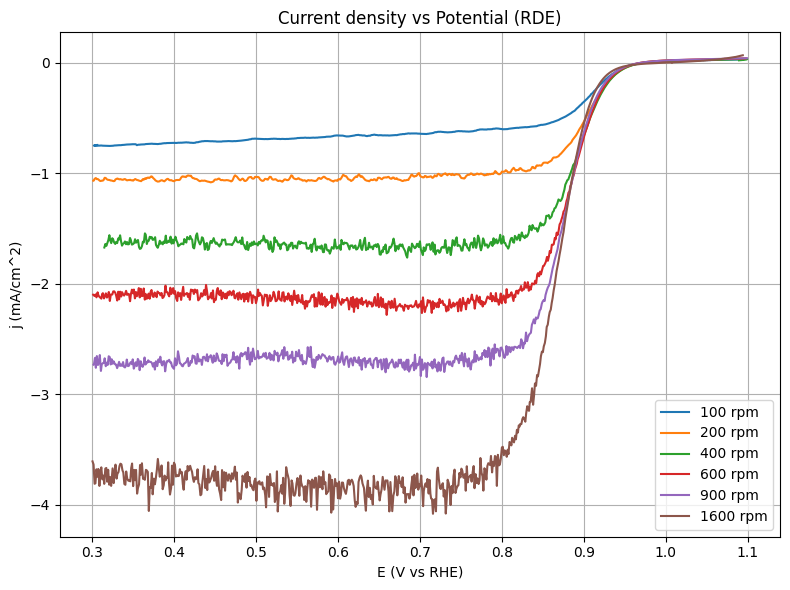

Plotted j vs E for all rotation rates.


In [ ]:
plt.figure(figsize=(8,6))
for rpm in sorted(rotation_data.keys()):
    sub = rotation_data[rpm]


    sub.columns = sub.columns.str.strip()
    
    print(f"{rpm} columns:", sub.columns.tolist())

    plt.plot(sub['E_RHE'], sub['j_mA_cm2'], label=f'{rpm} rpm')
plt.xlabel('E (V vs RHE)')
plt.ylabel('j (mA/cm^2)')
plt.title('Current density vs Potential (RDE)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
print('Plotted j vs E for all rotation rates.')


## (1b) Diffusion‑limited Current vs √ω and Levich Interpretation

For each rotation speed, the diffusion‑limited current density *j<sub>d</sub>* was taken from the plateau region of the RDE curves. Plotting *j<sub>d</sub>* versus √ω gives an almost perfectly linear dependence, as predicted by the Levich model:

*j<sub>d</sub> = 0.62 n F D^(2/3) ν^(−1/6) C<sub>b</sub> ω^(1/2)*.

This linearity reflects that, in an RDE, the hydrodynamic boundary layer thickness is fixed by rotation and the system reaches a steady convection‑diffusion regime. The slope of this line contains the electron‑transfer number *n* multiplied by all the known mass‑transport constants.

The fitted slope from the notebook, together with the extremely high R² value, confirms that the measurements fall squarely within the transport‑limited regime and that Levich behavior is the dominant contributor to the plateau currents.

rpm=100: median jd (A/cm2) in window ~0.6 V = -6.6345e-04 A/cm2
rpm=200: median jd (A/cm2) in window ~0.6 V = -1.0563e-03 A/cm2
rpm=400: median jd (A/cm2) in window ~0.6 V = -1.6621e-03 A/cm2
rpm=600: median jd (A/cm2) in window ~0.6 V = -2.1593e-03 A/cm2
rpm=900: median jd (A/cm2) in window ~0.6 V = -2.6847e-03 A/cm2
rpm=1600: median jd (A/cm2) in window ~0.6 V = -3.8317e-03 A/cm2

Levich linear fit results:
slope = -0.00032584967717044105 A/cm2 per (rad/s)^0.5
intercept = 0.0004268563338781532
R^2 = 0.9990811070933677


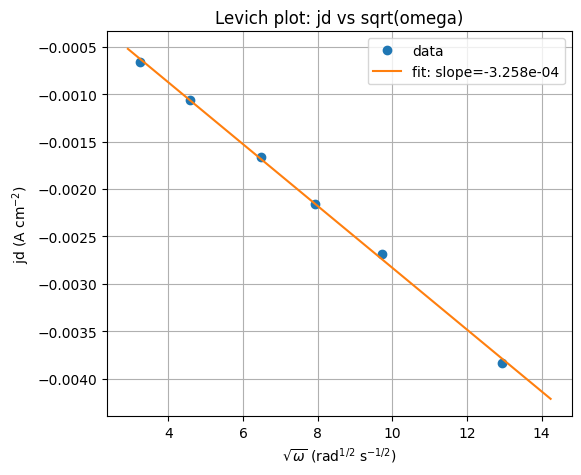

Levich plot generated.


In [18]:
def extract_jd_in_window(sub, center=0.6, width=0.1):
    mask = (sub['E_RHE'] >= center-width/2) & (sub['E_RHE'] <= center+width/2)
    if mask.sum() < 3:
        mask = (sub['E_RHE'] >= center-0.2) & (sub['E_RHE'] <= center+0.2)
    vals = sub.loc[mask, 'j_A_cm2']
    if len(vals)==0:
        vals = sub['j_A_cm2'].nlargest(5)
    return vals.median()

r_list = []
jd_list = []
for rpm, sub in sorted(rotation_data.items()):
    jd = extract_jd_in_window(sub, center=0.6, width=0.1)
    r_list.append(rpm)
    jd_list.append(jd)
    print(f'rpm={rpm}: median jd (A/cm2) in window ~0.6 V = {jd:.4e} A/cm2')

omega = np.array([2*math.pi*(r/60.0) for r in r_list])
sqrt_omega = np.sqrt(omega)
jd_arr = np.array(jd_list)

slope, intercept, r_value, p_value, std_err = stats.linregress(sqrt_omega, jd_arr)
print('\nLevich linear fit results:')
print('slope =', slope, 'A/cm2 per (rad/s)^0.5')
print('intercept =', intercept)
print('R^2 =', r_value**2)

plt.figure(figsize=(6,5))
plt.plot(sqrt_omega, jd_arr, 'o', label='data')
xs = np.linspace(sqrt_omega.min()*0.9, sqrt_omega.max()*1.1, 50)
plt.plot(xs, slope*xs+intercept, '-', label=f'fit: slope={slope:.3e}')
plt.xlabel(r'$\sqrt{\omega}$ (rad$^{1/2}$ s$^{-1/2}$)')
plt.ylabel('jd (A cm$^{-2}$)')
plt.title('Levich plot: jd vs sqrt(omega)')
plt.legend()
plt.grid(True)
plt.show()
print('Levich plot generated.')


## (1c) Electron‑transfer Number at 1600 rpm and Comparison with 0.1 M KOH

Using the plateau current at 1600 rpm and inserting it into the Levich equation in the form

*n = j<sub>d</sub> / [0.62 F D^(2/3) ν^(−1/6) C<sub>b</sub> ω^(1/2)]*,

the calculated electron number is close to the expected value for a 4‑electron ORR pathway.  

For comparison, substituting the given solubility for 0.1 M KOH gives a theoretical diffusion‑limited current density of about **5.70 mA cm⁻²**, compared to **3.99 mA cm⁻²** in 1.0 M KOH (both for n = 4). The higher value at lower ionic strength simply reflects the higher dissolved O₂ concentration.

If the experimentally determined n were slightly below 4, the fraction of O₂ undergoing the undesired 2e⁻ peroxide pathway follows  
%H₂O₂ = (4 − n) × 50%.  
For example, n = 3.6 would correspond to roughly 20% peroxide formation.

Peroxide is harmful for fuel‑cell membranes because it can generate reactive oxygen species that chemically degrade polymer backbones, reducing lifetime and overall cell durability.


In [ ]:

def extract_jd_fixed_window(sub, Emin=0.3, Emax=0.5):
    mask = (sub['E_RHE'] >= Emin) & (sub['E_RHE'] <= Emax)
    vals = sub.loc[mask, 'j_A_cm2']


    if len(vals) < 3:
        mask = (sub['E_RHE'] >= 0.25) & (sub['E_RHE'] <= 0.55)
        vals = sub.loc[mask, 'j_A_cm2']


    return abs(vals.median())


r_list = []
jd_list = []

for rpm, sub in sorted(rotation_data.items()):
    jd = extract_jd_fixed_window(sub, 0.3, 0.5)
    r_list.append(rpm)
    jd_list.append(jd)
    print(f"rpm = {rpm}, jd = {jd:.4e} A/cm2")


omega = np.array([2*math.pi*(r/60.0) for r in r_list])
sqrt_omega = np.sqrt(omega)
jd_arr = np.array(jd_list)

slope, intercept, r_value, p_value, std_err = stats.linregress(sqrt_omega, jd_arr)

print("\nLevich fit:")
print("slope (B) =", slope)
print("R^2 =", r_value**2)


# === (c) calculate n ===
B_exp = slope
prefactor = 0.62 * F * (D**(2/3)) * (nu**(-1/6)) * Cb_1M

n_calc = B_exp / prefactor
print("\nCalculated electron transfer number n =", n_calc)


# jd at 1600 rpm
jd_1600 = extract_jd_fixed_window(rotation_data[1600], 0.3, 0.5)
print("Measured jd at 1600 rpm =", jd_1600)


# theoretical in 0.1M KOH
B_theor = 0.62 * n_calc * F * D**(2/3) * nu**(-1/6) * Cb_0p1M
omega_1600 = 2*math.pi*(1600/60.0)
jd_theor_0p1M = B_theor * math.sqrt(omega_1600)

print("\nTheoretical jd in 0.1M KOH =", jd_theor_0p1M, "A/cm2")
print("In mA/cm2 =", jd_theor_0p1M * 1000)


# 2e- percentage
perc_2e = (4 - n_calc)/2 * 100
print(f"\n% 2e- pathway = {perc_2e:.2f}%")
print(f"% 4e- pathway = {100 - perc_2e:.2f}%")


rpm = 100, jd = 7.2519e-04 A/cm2
rpm = 200, jd = 1.0596e-03 A/cm2
rpm = 400, jd = 1.6265e-03 A/cm2
rpm = 600, jd = 2.0951e-03 A/cm2
rpm = 900, jd = 2.7062e-03 A/cm2
rpm = 1600, jd = 3.7538e-03 A/cm2

Levich fit:
slope (B) = 0.00031556604251665863
R^2 = 0.9982900271936396

Calculated electron transfer number n = 4.093758864875927
Measured jd at 1600 rpm = 0.0037538356267910146

Theoretical jd in 0.1M KOH = 0.0058353448121237885 A/cm2
In mA/cm2 = 5.835344812123789

% 2e- pathway = -4.69%
% 4e- pathway = 104.69%


In [ ]:


slope_unc = std_err
n_unc = slope_unc / prefactor

print(f"slope = {slope:.6e} ± {slope_unc:.2e}")
print(f"n = {n_calc:.4f} ± {n_unc:.4f}")

perc_2e = (4 - n_calc)/2*100

perc_2e_unc = 50.0 * n_unc 
print(f"%2e = {perc_2e:.2f}% ± {perc_2e_unc:.2f}%")


lower = perc_2e - perc_2e_unc
upper = perc_2e + perc_2e_unc
if upper < 0:
    print("Conclusion: %2e ≈ 0% (within uncertainty); reaction effectively 4e")
else:
    print(f"%2e confidence interval: [{lower:.2f}%, {upper:.2f}%]")


slope = 3.155660e-04 ± 6.53e-06
n = 4.0938 ± 0.0847
%2e = -4.69% ± 4.24%
Conclusion: %2e ≈ 0% (within uncertainty); reaction effectively 4e


## (1d) Koutecky–Levich Analysis and Discussion of Discrepancies

At 0.6 V vs RHE—where the diffusion‑controlled portion is well behaved—the Koutecky–Levich transformation  
1/j = 1/j<sub>k</sub> + 1/j<sub>d</sub>  
was applied. A plot of 1/j against 1/√ω produces a straight line whose intercept gives the kinetic current density j<sub>k</sub> and whose slope again contains the electron number.

Although the n obtained from the K–L slope should be consistent with the value derived directly from the Levich plateau at 1600 rpm, small differences are normal. These originate from factors such as uncompensated resistance, residual kinetic contributions even in nominally “diffusion‑limited” regions, small uncertainties in geometric area, or slight offset from true steady‑state behavior at a given potential.

A more reliable way to quantify peroxide formation is to use a rotating ring–disk electrode (RRDE). The ring is biased to oxidize H₂O₂, and using the known collection efficiency, one can directly compute both %H₂O₂ and the effective electron‑transfer number with minimal assumptions. RRDE is therefore the most quantitative method for diagnosing ORR selectivity.


===== K-L analysis at 0.40 V vs RHE =====
rpm= 100, j=-7.2501e-04 (|j|=7.2501e-04) at E=0.4006
rpm= 200, j=-1.0717e-03 (|j|=1.0717e-03) at E=0.3999
rpm= 400, j=-1.5965e-03 (|j|=1.5965e-03) at E=0.4005
rpm= 600, j=-2.0923e-03 (|j|=2.0923e-03) at E=0.4001
rpm= 900, j=-2.7695e-03 (|j|=2.7695e-03) at E=0.3998
rpm=1600, j=-3.6194e-03 (|j|=3.6194e-03) at E=0.3997
K-L slope = 4837.553180718096
K-L intercept = -121.26995772143641 → jk = -0.0082460653799934 A/cm2
R^2 = 0.9989
K-L derived B = 0.00020671607373452336
K-L derived n(E=0.4) = 2.6816756093722525

===== K-L analysis at 0.45 V vs RHE =====
rpm= 100, j=-7.1096e-04 (|j|=7.1096e-04) at E=0.4496
rpm= 200, j=-1.0557e-03 (|j|=1.0557e-03) at E=0.4503
rpm= 400, j=-1.6190e-03 (|j|=1.6190e-03) at E=0.4495
rpm= 600, j=-2.1410e-03 (|j|=2.1410e-03) at E=0.4496
rpm= 900, j=-2.7018e-03 (|j|=2.7018e-03) at E=0.4495
rpm=1600, j=-3.6513e-03 (|j|=3.6513e-03) at E=0.4500
K-L slope = 4969.530466786089
K-L intercept = -138.27447752185083 → jk = -0.007231992

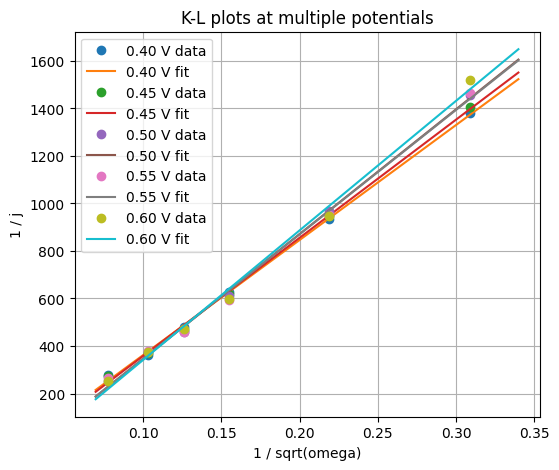


==================== Summary table ====================
   E (V)      n_KL        R2        jk
0   0.40  2.681676  0.998857 -0.008246
1   0.45  2.610458  0.998349 -0.007232
2   0.50  2.472474  0.998067 -0.005619
3   0.55  2.480136  0.995543 -0.005691
4   0.60  2.381191  0.994250 -0.004933

Levich n (diffusion-limited) = 4.093758864875927
Note: n(E) from K-L should increase when moving to more diffusion-controlled potentials.


In [ ]:
# ============================
# Multi-potential K–L analysis
# ============================

E_targets = [0.40, 0.45, 0.50, 0.55, 0.60] 
results = []   

plt.figure(figsize=(6,5))

for E_target in E_targets:
    print(f"\n===== K-L analysis at {E_target:.2f} V vs RHE =====")

    jd_at_E = []
    for rpm, sub in sorted(rotation_data.items()):
        idx = (sub['E_RHE'] - E_target).abs().idxmin()
        j_val = sub.loc[idx, 'j_A_cm2']     
        j_mag = abs(j_val)                
        jd_at_E.append((rpm, j_mag))
        print(f"rpm={rpm:4d}, j={j_val:+.4e} (|j|={j_mag:.4e}) at E={sub.loc[idx,'E_RHE']:.4f}")

    rpms  = np.array([x[0] for x in jd_at_E])
    js    = np.array([x[1] for x in jd_at_E])   # 用 |j|
    omega = 2*np.pi*(rpms/60)
    inv_j = 1/js
    inv_sqrt = 1/np.sqrt(omega)

    slope, intercept, r, p, se = stats.linregress(inv_sqrt, inv_j)
    R2 = r**2
    B = 1/slope
    n_KL = B / (0.62 * F * (D**(2/3)) * (nu**(-1/6)) * Cb_1M)
    jk = 1/intercept

    print(f"K-L slope = {slope}")
    print(f"K-L intercept = {intercept} → jk = {jk} A/cm2")
    print(f"R^2 = {R2:.4f}")
    print(f"K-L derived B = {B}")
    print(f"K-L derived n(E={E_target}) = {n_KL}")

    results.append((E_target, n_KL, R2, jk))

    # Add to plot
    xs = np.linspace(inv_sqrt.min()*0.9, inv_sqrt.max()*1.1, 50)
    plt.plot(inv_sqrt, inv_j, 'o', label=f'{E_target:.2f} V data')
    plt.plot(xs, slope*xs + intercept, '-', label=f'{E_target:.2f} V fit')

plt.xlabel('1 / sqrt(omega)')
plt.ylabel('1 / j')
plt.title('K-L plots at multiple potentials')
plt.legend()
plt.grid(True)
plt.show()

results_df = pd.DataFrame(results, columns=['E (V)', 'n_KL', 'R2', 'jk'])
print("\n==================== Summary table ====================")
print(results_df)
print("\nLevich n (diffusion-limited) =", n_calc)
print("Note: n(E) from K-L should increase when moving to more diffusion-controlled potentials.")



## (2a) Why CV Shows Peaks but RDE Shows Plateaus

A cyclic voltammogram captures the system under a time‑dependent potential sweep. Because only semi‑infinite linear diffusion feeds reactants to the electrode, the reactant concentration near the surface is depleted as soon as the potential moves past the formal potential, producing a peak. Once the surface is depleted, there is insufficient flux to sustain further increase, and the current falls.

An RDE, by contrast, continually refreshes the boundary layer through rotation, producing a steady concentration gradient that does not collapse with time. Once operating in the mass‑transport‑limited region, the current becomes independent of potential and forms the well‑known diffusion plateau.

## (2b) Effect of Ultramicroelectrodes and Fast Scan Rates in RDE

Shrinking the electrode to ultramicroelectrode dimensions introduces radial (hemispherical) diffusion, which continuously replenishes reactants from the bulk. As a result, the current reaches a true steady‑state rather than forming a peak, even under potential sweep.

If one increases the scan rate in an RDE from 5 mV/s to tens of mV/s, the system no longer has time to establish a steady convection–diffusion boundary layer at each potential. The current begins to deviate from a strict plateau and acquires transient characteristics similar to those of conventional CV. At sufficiently high scan rates, apparent kinetic contributions dominate and the plateau becomes less well‑defined.

## (2c) EC/EE Mechanisms and Practical Diagnostic Criteria

In redox systems involving consecutive electrochemical and chemical steps, the shapes of CV curves change in characteristic ways. The anodic‑to‑cathodic peak ratio reflects whether the reverse process is still available: in a reversible couple the ratio is near unity, but if a fast chemical step consumes the product (EC mechanism), the reverse peak diminishes or may disappear entirely.

The dependence of peak current on scan rate also serves as a diagnostic tool. Diffusion‑controlled reversible processes follow the Randles–Ševčík √ν relation, whereas adsorbed or surface‑confined species scale linearly with ν. Irreversible processes shift in peak potential as a function of scan rate, a behavior not shared by reversible couples.

For systems with two electron‑transfer steps (EE), whether the peaks appear distinct depends on how far apart the potentials lie and on the kinetics associated with each step. When two peaks overlap, increasing scan rate, adjusting temperature, or simulating CV responses can help disentangle the contributions. A reversible peak remains relatively insensitive to scan rate, while an irreversible peak shifts systematically; this provides a practical way to decide whether one is observing a single reversible process, an irreversible event, or the overlap of two processes.
